# Specialise in second-order systems

In this tutorial, we see how second-order ODEs can (and should!) be solved
without transforming them into first-order problems first.

For a related demonstration, refer to the custom information operator tutorial.

In [1]:
"""Demonstrate how to solve second-order IVPs without transforming them first."""

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from diffeqzoo import backend, ivps

from probdiffeq import ivpsolve, probdiffeq, taylor

# Fail this notebook on NaN detection (to catch those in the CI)
jax.config.update("jax_debug_nans", True)


if not backend.has_been_selected:
    backend.select("jax")  # ivp examples in jax

Quick refresher: first-order ODEs.

In [2]:
f, u0, (t0, t1), f_args = ivps.three_body_restricted_first_order()


@jax.jit
def vf_1(y, /, *, t):
    """Evaluate the three-body problem as a first-order IVP."""
    del t
    return f(y, *f_args)


tcoeffs = taylor.odejet_padded_scan(lambda y: vf_1(y, t=t0), (u0,), num=4)

init, ssm = probdiffeq.ssm_taylor(tcoeffs, ssm_fact="isotropic")
iwp = probdiffeq.prior_wiener_integrated(ssm=ssm, output_scale=1.0)
ts0 = probdiffeq.constraint_ode_ts0(vf_1, ssm=ssm)
strategy = probdiffeq.strategy_filter(ssm=ssm)
solver_1st = probdiffeq.solver_mle(
    strategy=strategy, prior=iwp, constraint=ts0, ssm=ssm
)
error_1st = probdiffeq.error_residual_std(constraint=ts0, prior=iwp, ssm=ssm)

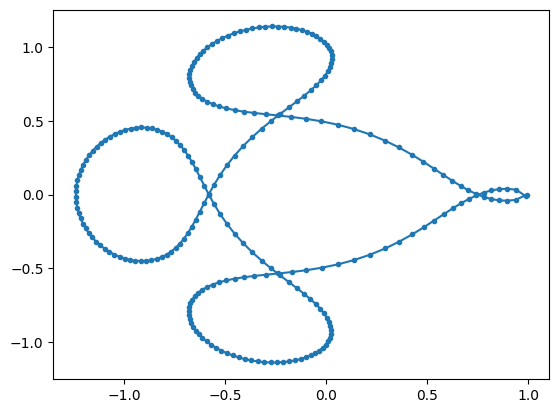

In [3]:
save_at = jnp.linspace(t0, t1, endpoint=True, num=250)
solve = ivpsolve.solve_adaptive_save_at(solver=solver_1st, error=error_1st)
solution = jax.jit(solve)(init, save_at=save_at, atol=1e-5, rtol=1e-5)
plt.plot(solution.u.mean[0][:, 0], solution.u.mean[0][:, 1], marker=".")
plt.show()

The default configuration assumes that the ODE to be solved is of first order.
Now, the same game with a second-order ODE

In [4]:
f, (u0, du0), (t0, t1), f_args = ivps.three_body_restricted()


@jax.jit
def vf_2(y, dy, /, *, t):
    """Evaluate the three-body problem as a second-order IVP."""
    del t
    return f(y, dy, *f_args)


# Different derivative count because we don't transform to first order
# The goal is to match the number of tracked taylor coefficients.
tcoeffs = taylor.odejet_padded_scan(lambda *ys: vf_2(*ys, t=t0), (u0, du0), num=3)
init, ssm = probdiffeq.ssm_taylor(tcoeffs, ssm_fact="isotropic")
iwp = probdiffeq.prior_wiener_integrated(ssm=ssm, output_scale=1.0)
ts0 = probdiffeq.constraint_ode_ts0(vf_2, ssm=ssm)
strategy = probdiffeq.strategy_filter(ssm=ssm)
solver_2nd = probdiffeq.solver_mle(
    strategy=strategy, prior=iwp, constraint=ts0, ssm=ssm
)
error_2nd = probdiffeq.error_residual_std(constraint=ts0, prior=iwp, ssm=ssm)

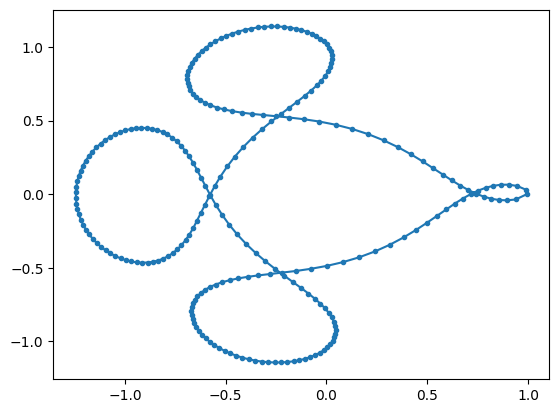

In [5]:
solve = ivpsolve.solve_adaptive_save_at(solver=solver_2nd, error=error_2nd)
solution = jax.jit(solve)(init, save_at=save_at, atol=1e-5, rtol=1e-5)

plt.plot(solution.u.mean[0][:, 0], solution.u.mean[0][:, 1], marker=".")
plt.show()

The results are indistinguishable from the plot.